In [36]:
import yaml
import numpy as np
from scipy.stats import ks_2samp, gaussian_kde, wasserstein_distance
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from metrics.statistic import compute_cov
import pandas as pd
from scipy.stats import wasserstein_distance as w1dist, pearsonr
from factor_model import FactorModel, reconstruct_returns, load_model


with open("cfg.yaml") as f:
    _cfg = yaml.safe_load(f)

PREFIX       = _cfg["train"]["prefix"]
FACTOR_NAMES = _cfg["train"]["factor_names"]   # includes market
NUM_GENERATE = _cfg["sample"]["num_generate"]

## TL;DR

- In factor level, the diffusion model performance is the same level as the resample baseline, and both are better than the Gaussian baseline.
- Diffusion model fail to capture the factor relationship.
- All methodology have hard time in stock level evaluation, and diffusion model is even worse, and the problem is more in the idiosyncratic modeling than the systematic modeling.

## Experimental Setup

Datasets: 2001 - 2025 daily returns and characteristics. 2025 are held out as OOS test set (261 samples), 2001-2024 are used for training (6262 samples).

Baselines:
- Resample: Randomly resample rows from the training dataset with replacement.
- Gaussian: Fit a multivariate Gaussian to the training data and sample from it. (factor evaluation only)


The evaluation are in factor level and stock level. For factor evaluation. The selected factor returns are `[market, growth, momentum, quality, size, value, volatility]` which are generated via OLS on each date. For stock evaluation, we only evaluate the stocks that both in the training set and test set.

In [18]:
model = load_model(PREFIX)
test_model = load_model(f"{PREFIX}/test")
print(PREFIX)

model/regression


In [19]:
sampled = np.load(f"{PREFIX}/samples/factor_{NUM_GENERATE}.npy")
print(f"{PREFIX}/samples/factor_{NUM_GENERATE}.npy")

model/regression/samples/factor_4096.npy


In [20]:
# training ds
train = model.F

# get the resampled baseline
rng = np.random.default_rng(42)
cov = np.cov(train.drop(columns=['alpha']).values, rowvar=False)
sampled_gaussian = rng.multivariate_normal(mean=train.drop(columns=['alpha']).mean().values, cov=cov, size=NUM_GENERATE)

# test ds
OOS = test_model.F.drop(columns=['alpha']).values
row_idx = rng.choice(train.shape[0], size=len(sampled), replace=True)
baselines = [("Resample", train.iloc[row_idx].drop(columns=['alpha']).values,'#17becf'), ("Gaussion", sampled_gaussian, '#ff7f0e')]
print(f"OOS: {OOS.shape}  sampled: {sampled.shape}  Gaussian: {sampled_gaussian.shape}")

OOS: (260, 7)  sampled: (4096, 7)  Gaussian: (4096, 7)


## Mahalanobis Check

Mahalanobis distance is a multivariate measure of how far a point is from the mean of a distribution, taking into account the covariance structure. If the generated samples are from the same distribution as the OOS data, their squared Mahalanobis distances should approximately follow a chi-squared distribution with degrees of freedom equal to the number of factors.

Left graph shows the result of the OOS data, it can be seen that our factor return has fat tail. Right graph show our generated samples and the resample/multivariate baseline. And the diffusion model can capture the tail behavior while multivariate Gaussian fails to do

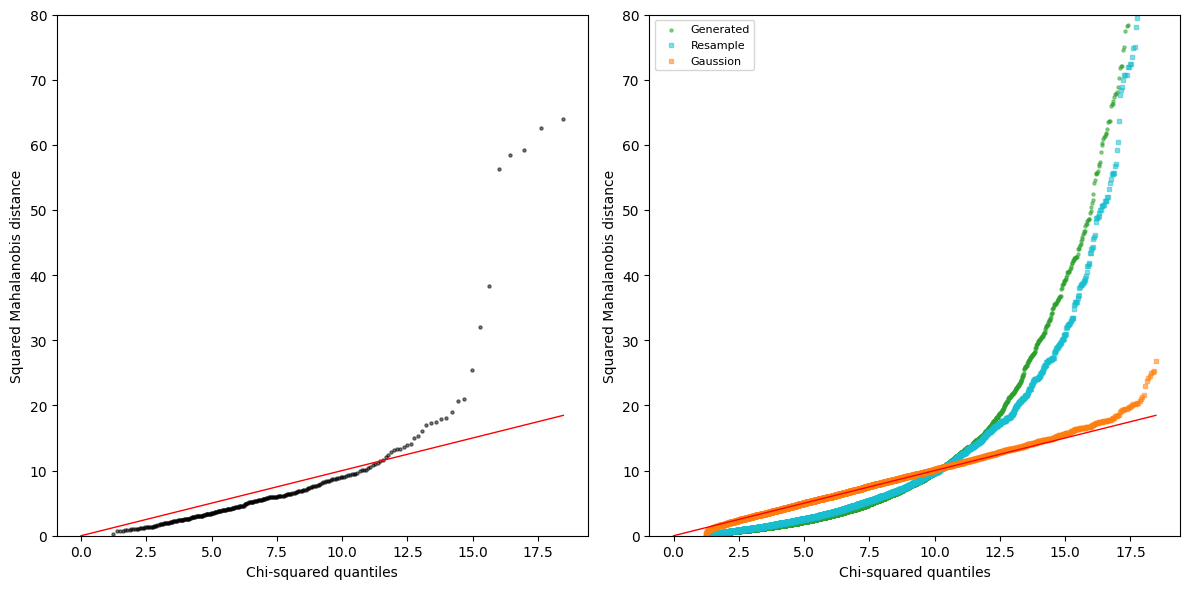

In [21]:

def mahal_d2(X):
    mean = X.mean(axis=0)
    cov  = np.cov(X, rowvar=False)
    diff = X - mean
    return (diff @ np.linalg.pinv(cov) * diff).sum(axis=1)

def plot_mahal(ax, X, label, color='steelblue', marker='o', size=5, alpha=0.5):
    p  = X.shape[1]
    d2 = mahal_d2(X)
    qs = stats.chi2.ppf(np.linspace(0.01, 0.99, len(d2)), df=p)
    ax.scatter(qs, np.sort(d2), s=size, alpha=alpha, color=color,
               marker=marker, label=label)
    return qs.max()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Left panel: OOS
q_max = plot_mahal(ax1, OOS, 'OOS', color='black')
ax1.plot([0, q_max], [0, q_max], color='red', linewidth=1)
ax1.set_ylim(0, 80)
ax1.set_xlabel('Chi-squared quantiles')
ax1.set_ylabel('Squared Mahalanobis distance')

# Right panel: Generated + Baselines overlaid
q_max2 = plot_mahal(ax2, sampled, 'Generated', color='#2ca02c')
for (bname, bdata, bc) in baselines:
    q_max2 = max(q_max2, plot_mahal(ax2, bdata, bname, color=bc, marker='s'))
ax2.plot([0, q_max2], [0, q_max2], color='red', linewidth=1)
ax2.set_ylim(0, 80)
ax2.set_xlabel('Chi-squared quantiles'); ax2.set_ylabel('Squared Mahalanobis distance')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Moment Comparison (factor level)

Comparing moments (mean, std, skewness, kurtosis) per factor of the generated samples and baseline against the OOS data.
we use MAE (mean absolute error) to summarize the deviation of each moment across factors. The scatter plots show the per-factor moments of generated/baseline vs OOS, with a 45-degree reference line. From the illustration, all methodology can capture the mean and std well, diffusion model capture the kurtosis better and resample baseline capture the skewness better. And they are all better than the Gaussian baseline.

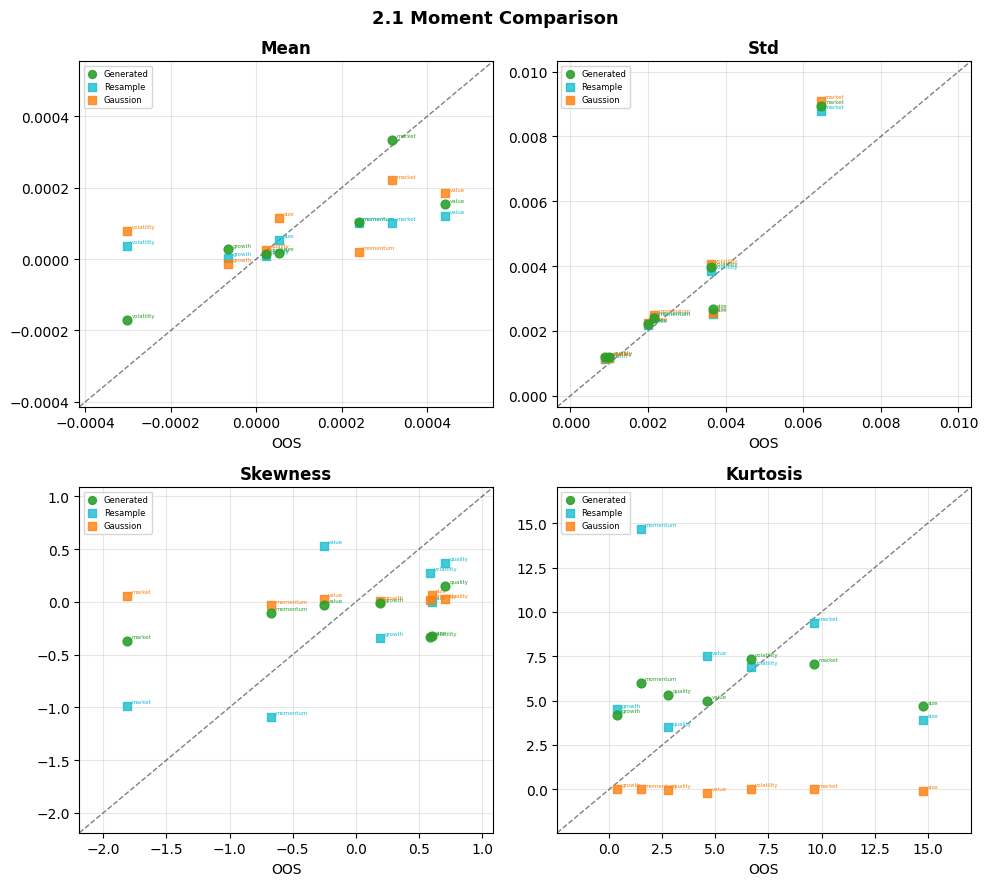

In [22]:

def compute_moments(data):
    return [np.mean(data, axis=0), np.std(data, axis=0),
            stats.skew(data, axis=0), stats.kurtosis(data, axis=0)]


moment_names = ['Mean', 'Std', 'Skewness', 'Kurtosis']
m_OOS    = compute_moments(OOS)
m_gen    = compute_moments(sampled)
m_bases  = [(name, compute_moments(data), c) for name, data, c in baselines]

ANNOT_FS = 4
LEGEND_FS = 6
PT_SIZE   = 40

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for idx, (ax, mname) in enumerate(zip(axes.flatten(), moment_names)):
    OOS_m = m_OOS[idx]
    gen_m = m_gen[idx]
    all_y = [gen_m] + [bm[idx] for _, bm, _ in m_bases]

    lim = [min(OOS_m.min(), min(y.min() for y in all_y)),
           max(OOS_m.max(), max(y.max() for y in all_y))]
    pad = (lim[1] - lim[0]) * 0.15 or 0.01
    lim = [lim[0] - pad, lim[1] + pad]

    ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)
    ax.scatter(OOS_m, gen_m, color='#2ca02c', s=PT_SIZE, marker='o', zorder=4,
               label='Generated', alpha=0.9)
    for i, fn in enumerate(FACTOR_NAMES):
        ax.annotate(fn, (OOS_m[i], gen_m[i]), fontsize=ANNOT_FS,
                    xytext=(3, 2), textcoords='offset points', color='#2ca02c')
    for (bname, bm, bc) in m_bases:
        ax.scatter(OOS_m, bm[idx], color=bc, s=PT_SIZE, marker='s', zorder=3,
                   label=bname, alpha=0.8)
        for i, fn in enumerate(FACTOR_NAMES):
            ax.annotate(fn, (OOS_m[i], bm[idx][i]), fontsize=ANNOT_FS,
                        xytext=(3, 2), textcoords='offset points', color=bc)

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('OOS')
    ax.set_title(mname, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=LEGEND_FS, markerscale=0.9, handlelength=1.2)

fig.suptitle('2.1 Moment Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
def fmt_mae(errs):
    return f"{np.mean(errs):.4f} ({np.std(errs):.4f})"

col_w = 22
header = f"{'Moment':<12}" + f"{'Generated':<{col_w}}" + \
         "".join(f"{bname:<{col_w}}" for bname, _, _ in m_bases)
print("MAE across factors — mean (std):")
print(header)
print("-" * len(header))
for idx, mname in enumerate(moment_names):
    row = f"{mname:<12}{fmt_mae(np.abs(m_gen[idx] - m_OOS[idx])):<{col_w}}"
    for _, bm, _ in m_bases:
        row += f"{fmt_mae(np.abs(bm[idx] - m_OOS[idx])):<{col_w}}"
    print(row)

MAE across factors — mean (std):
Moment      Generated             Resample              Gaussion              
------------------------------------------------------------------------------
Mean        0.0001 (0.0001)       0.0002 (0.0001)       0.0002 (0.0001)       
Std         0.0007 (0.0008)       0.0007 (0.0008)       0.0007 (0.0008)       
Skewness    0.6919 (0.4065)       0.5458 (0.1893)       0.6811 (0.5136)       
Kurtosis    3.5210 (3.0251)       4.6070 (4.9193)       5.8091 (4.7249)       


## Distribution Comparison

We draw KDE(kernel density estimation) plots for each factor, comparing the OOS distribution with the generated samples and baselines. We also compute the Wasserstein-1 distance to measure similarity between marginal distributions.

The KDE plots show that the diffusion model (Generated) closely tracks the OOS density across all seven factors, reproducing both the sharp peak and fat tails. The Gaussian baseline consistently underestimates peak density and underestimates tails. Resample performs comparably to Generated in shape.

The Wasserstein-1 distances shows Generated achieves W1 comparable to or lower than Resample for all factors, while Gaussian is consistently higher — most notably for `market` (0.0032 vs 0.0018) and `volatility` (0.0009 vs 0.0004).


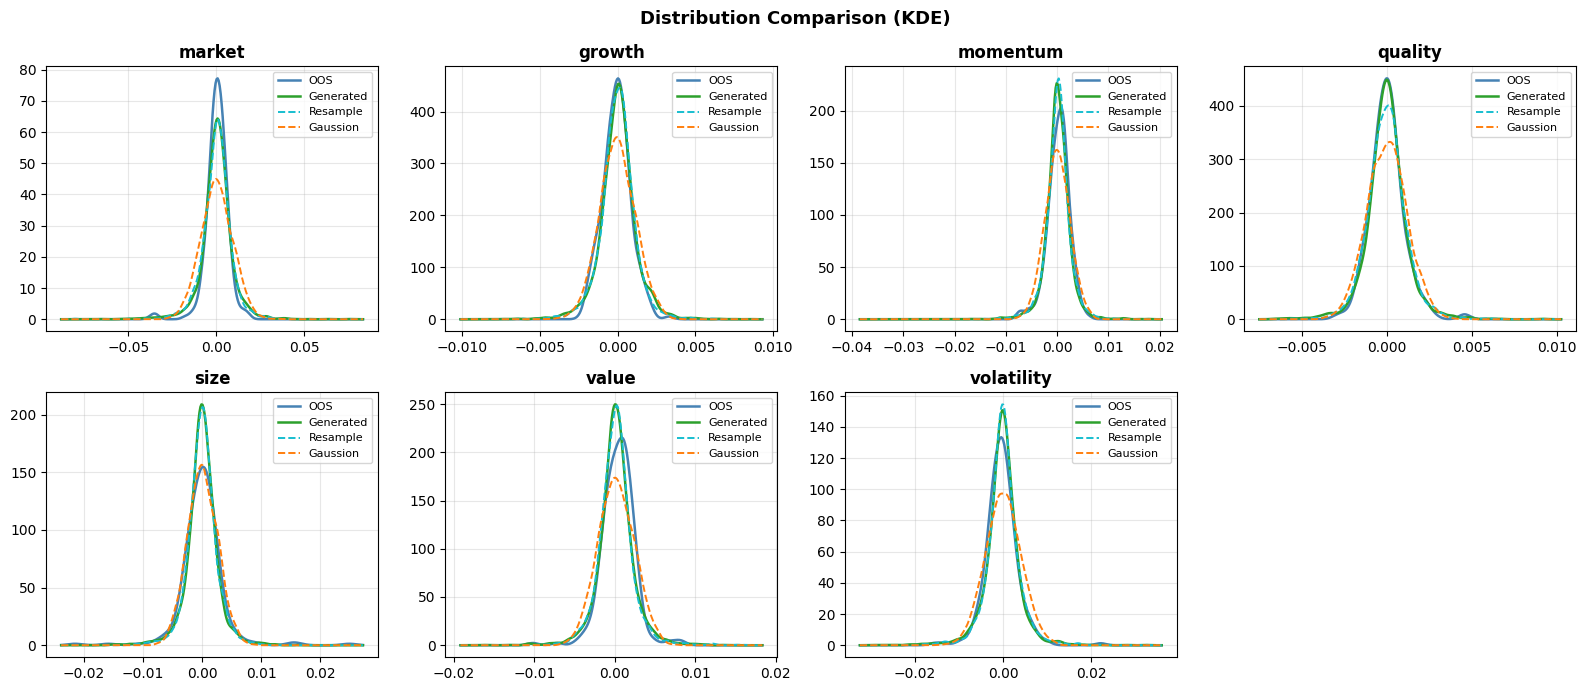

In [24]:
n_factors = len(FACTOR_NAMES)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, name, i in zip(axes.flatten(), FACTOR_NAMES, range(n_factors)):
    OOS_vals    = OOS[:, i]
    gen_vals    = sampled[:, i]

    all_vals = np.concatenate([OOS_vals, gen_vals] +
                              [bdata[:, i] for _, bdata, _ in baselines])
    x_min, x_max = all_vals.min(), all_vals.max()
    pad = (x_max - x_min) * 0.05
    x = np.linspace(x_min - pad, x_max + pad, 300)

    for vals, label, color, ls, lw in [
        (OOS_vals,   'OOS',       'steelblue', '-', 1.8),
        (gen_vals,   'Generated', '#2ca02c',     '-', 1.8),
    ]:
        ax.plot(x, gaussian_kde(vals)(x), label=label, color=color, lw=lw, ls=ls)

    for (bname, bdata, bc) in baselines:
        ax.plot(x, gaussian_kde(bdata[:, i])(x),
                label=bname, color=bc, lw=1.4, ls='--')

    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes.flatten()[n_factors:]:
    ax.set_visible(False)

fig.suptitle('Distribution Comparison (KDE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
col_w = 14
header = f"{'Factor':<14}" + f"{'Generated':<{col_w}}" + \
         "".join(f"{bname:<{col_w}}" for bname, _, _ in baselines)
print("Wasserstein-1 Distance:")
print(header)
print("-" * len(header))
for i, name in enumerate(FACTOR_NAMES):
    w1_gen = wasserstein_distance(OOS[:, i], sampled[:, i])
    row = f"{name:<14}{w1_gen:<{col_w}.4f}"
    for _, bdata, _ in baselines:
        row += f"{wasserstein_distance(OOS[:, i], bdata[:, i]):<{col_w}.4f}"
    print(row)
avg_gen = np.mean([wasserstein_distance(OOS[:, i], sampled[:, i]) for i in range(n_factors)])
avgs_b  = [np.mean([wasserstein_distance(OOS[:, i], bdata[:, i]) for i in range(n_factors)])
           for _, bdata, _ in baselines]

Wasserstein-1 Distance:
Factor        Generated     Resample      Gaussion      
--------------------------------------------------------
market        0.0018        0.0018        0.0032        
growth        0.0002        0.0002        0.0002        
momentum      0.0003        0.0003        0.0005        
quality       0.0001        0.0001        0.0002        
size          0.0004        0.0004        0.0005        
value         0.0004        0.0004        0.0005        
volatility    0.0004        0.0004        0.0009        


## QQ plot

Q-Q plots compare the quantiles of the generated samples and baselines against the OOS data for each factor. It gives another view of the factor distributional similarity, especially in the tails. We can see `market` factor is not well described by all methodology. On other factors there are some mismatch on tail but roughly the follows the 45 degree line.

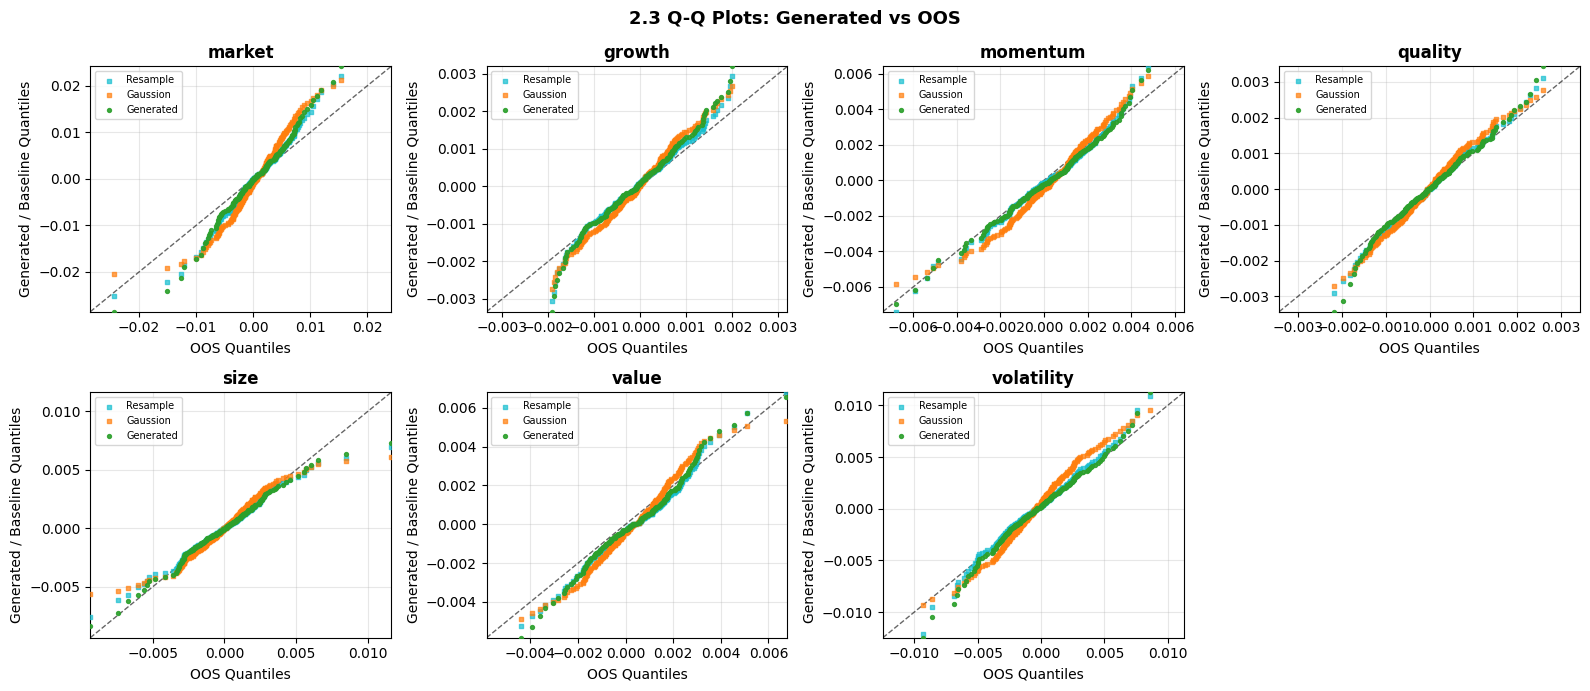

In [26]:
# Quantile-Quantile (Q-Q) Plots
n_quantiles = 200
probs = np.linspace(0.01, 0.99, n_quantiles)
n_factors = len(FACTOR_NAMES)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, name, i in zip(axes.flatten(), FACTOR_NAMES, range(n_factors)):
    q_OOS  = np.quantile(OOS[:, i],      probs)
    q_gen  = np.quantile(sampled[:, i],  probs)

    all_q = [q_OOS, q_gen] + [np.quantile(bdata[:, i], probs) for _, bdata, _ in baselines]
    lim = [min(q.min() for q in all_q), max(q.max() for q in all_q)]

    for (bname, bdata, bc) in baselines:
        q_base = np.quantile(bdata[:, i], probs)
        ax.scatter(q_OOS, q_base, s=8, color=bc, zorder=3,
                   label=bname, alpha=0.7, marker='s')

    ax.scatter(q_OOS, q_gen, s=8, color='#2ca02c', zorder=4, label='Generated', alpha=0.9)

    ax.plot(lim, lim, 'k--', lw=1, alpha=0.6)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('OOS Quantiles')
    ax.set_ylabel('Generated / Baseline Quantiles')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# hide unused subplots
for ax in axes.flatten()[n_factors:]:
    ax.set_visible(False)

fig.suptitle('2.3 Q-Q Plots: Generated vs OOS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Kolmogorov–Smirnov test

The Kolmogorov–Smirnov (KS) test is a non-parametric test that compares the empirical distribution functions of two RV. A higher p-value indicates that we cannot reject the null hypothesis that the two RV come from the same distribution.
 Diffusion model have (4/7) factors better than the resample baseline. And (4/7) factors pass the test if set threshold at 0.05.

In [27]:
# KS Test
ks_gen   = [ks_2samp(OOS[:, i], sampled[:, i]).pvalue for i in range(len(FACTOR_NAMES))]
ks_bases = [(bname, [ks_2samp(OOS[:, i], bdata[:, i]).pvalue
                     for i in range(len(FACTOR_NAMES))])
            for bname, bdata, _ in baselines]

col_w = 16
header = f"{'Factor':<18} {'Generated':<{col_w}}" + \
         "".join(f"{bname:<{col_w}}" for bname, _ in ks_bases)
print(f"KS p-value")
print(header)
print("-" * len(header))
for j, name in enumerate(FACTOR_NAMES):
    row = f"{name:<18} {ks_gen[j]:<{col_w}.4f}"
    for _, bks in ks_bases:
        row += f"{bks[j]:<{col_w}.4f}"
    print(row)

KS p-value
Factor             Generated       Resample        Gaussion        
-------------------------------------------------------------------
market             0.0400          0.0095          0.0000          
growth             0.1664          0.1973          0.0031          
momentum           0.0387          0.0395          0.0070          
quality            0.6017          0.4977          0.0074          
size               0.4565          0.5710          0.3447          
value              0.0009          0.0002          0.0032          
volatility         0.2298          0.0814          0.0006          


## Factor movement

Correlation matrix heatmaps of the OOS data, generated samples, and baselines. And we use the Fresenius distance between covariance matrices of test data and sampled data to summarize the overall similarity in factor relationships. The heatmaps show that the diffusion samples are very bad in capturing the factor relationship.

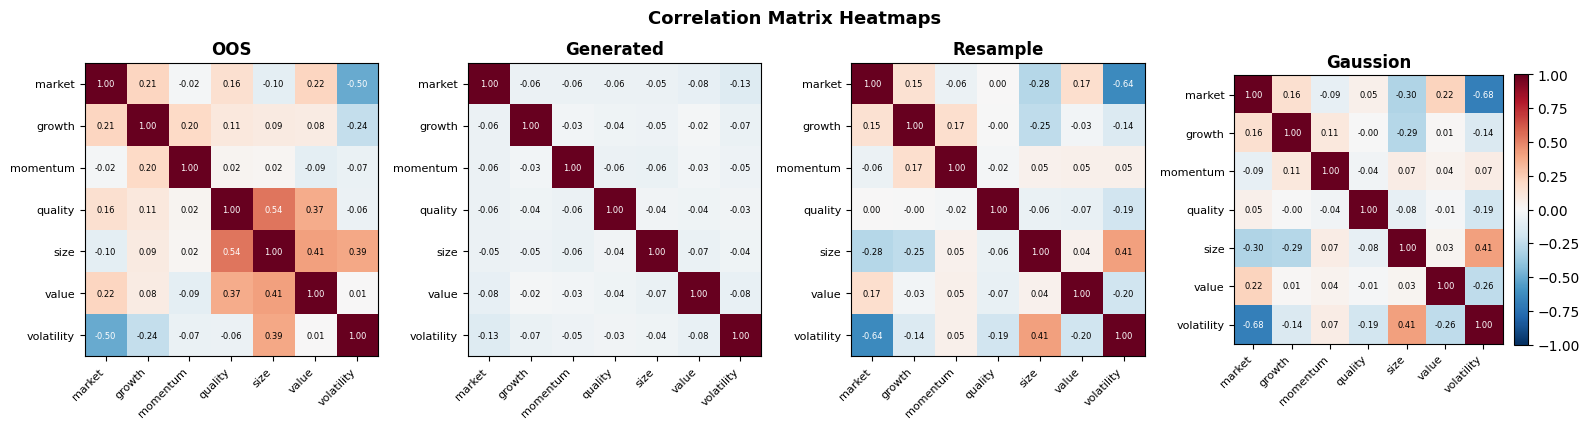

In [28]:
def corr_mat(data):
    return np.corrcoef(data, rowvar=False)

corr_OOS  = corr_mat(OOS)
corr_gen  = corr_mat(sampled)
corr_base = [(bname, corr_mat(bdata), bc) for bname, bdata, bc in baselines]

all_corrs = [('OOS', corr_OOS, 'steelblue'),
             ('Generated', corr_gen, '#2ca02c')] + corr_base

n = len(all_corrs)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.2))
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for ax, (name, corr, _) in zip(axes, all_corrs):
    im = ax.imshow(corr, cmap='RdBu_r', norm=norm)
    ax.set_xticks(range(len(FACTOR_NAMES)))
    ax.set_yticks(range(len(FACTOR_NAMES)))
    ax.set_xticklabels(FACTOR_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(FACTOR_NAMES, fontsize=8)
    ax.set_title(name, fontweight='bold')
    for ii in range(len(FACTOR_NAMES)):
        for jj in range(len(FACTOR_NAMES)):
            ax.text(jj, ii, f'{corr[ii, jj]:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(corr[ii, jj]) > 0.5 else 'black')

fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04)
fig.suptitle('Correlation Matrix Heatmaps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
print("Relative Frobenius Distance of Covariance Matrix")
print(f"  {'Generated':<16} {compute_cov(sampled, OOS):.4f}")
for bname, bdata, _ in baselines:
    print(f"  {bname:<16} {compute_cov(bdata, OOS):.4f}")

Relative Frobenius Distance of Covariance Matrix
  Generated        0.8393
  Resample         0.7911
  Gaussion         0.9316


## PCA Projection

We perform PCA on the training set to identify the main axes of variation and project all datasets (test dataset & generated) onto the top 2 PCs for visualization.

PC 1 (76.8% variance, dominated by the `market` factor) captures the primary source of variation. In the left panel, Train and Test overlap well in the central region, but OOS contains several extreme points along PC1 that fall outside the training bulk, which are unseen patterns in the training data.

In the right panel, the three methods show a clear ordering by spread: Gaussian is tightly concentrated at the center, Resample covers a range comparable to training data, and Generated extends furthest along PC1, wider even than the OOS range

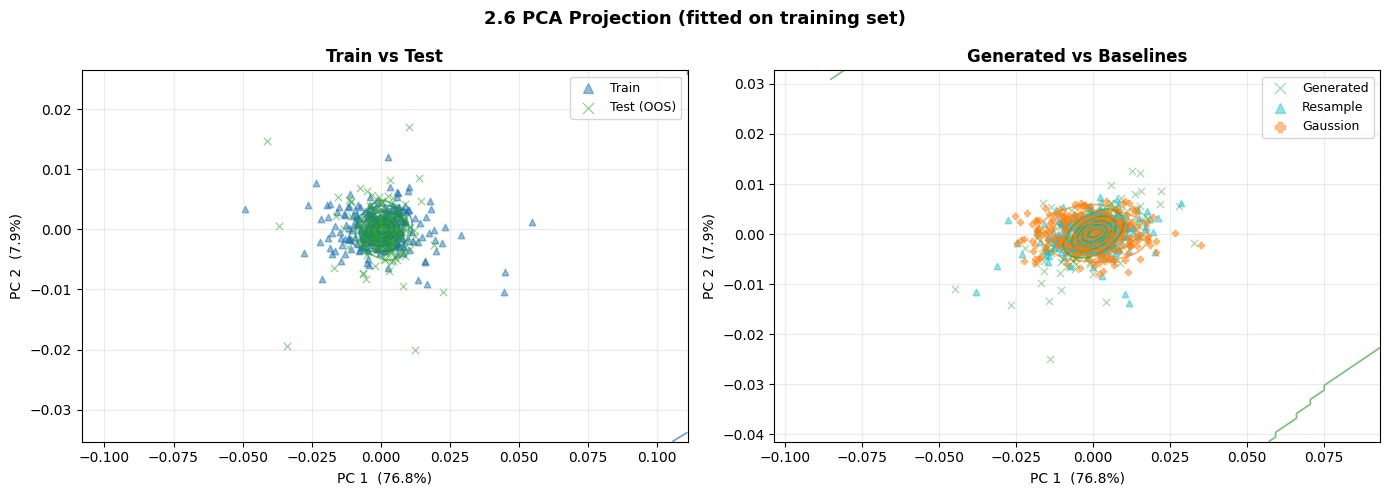

In [30]:
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

train_vals = train.drop(columns=['alpha']).values

pca = PCA(n_components=2)
pca.fit(train_vals)

train_pc = pca.transform(train_vals)
OOS_pc   = pca.transform(OOS)
gen_pc   = pca.transform(sampled)
base_pcs = [(bname, pca.transform(bdata), bc) for bname, bdata, bc in baselines]

xlab = f"PC 1  ({pca.explained_variance_ratio_[0]*100:.1f}%)"
ylab = f"PC 2  ({pca.explained_variance_ratio_[1]*100:.1f}%)"

N_SUB   = 300
C1, C2  = '#1a6faf', '#2ca02c'
MARKERS = ['^', 'P', 'D', 's']

def _sub(arr, n=N_SUB, seed=0):
    idx = np.random.default_rng(seed).choice(len(arr), size=min(n, len(arr)), replace=False)
    return arr[idx]

def _contour(ax, pc, color, levels=5, lw=1.2):
    kde  = gaussian_kde(pc.T)
    pad  = (pc.max(axis=0) - pc.min(axis=0)) * 0.15
    lo, hi = pc.min(axis=0) - pad, pc.max(axis=0) + pad
    xx, yy = np.mgrid[lo[0]:hi[0]:80j, lo[1]:hi[1]:80j]
    z = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    ax.contour(xx, yy, z, levels=levels, colors=[color], alpha=0.65, linewidths=lw)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


_contour(ax1, train_pc, C1)
_contour(ax1, OOS_pc,   C2)
ax1.scatter(*_sub(train_pc, seed=0).T, c=C1, marker='^', s=22, alpha=0.45, label='Train')
ax1.scatter(*_sub(OOS_pc,   seed=1).T, c=C2, marker='x', s=28, alpha=0.55,
            label='Test (OOS)', linewidths=0.8)
ax1.set_xlabel(xlab); ax1.set_ylabel(ylab)
ax1.set_title('Train vs Test', fontweight='bold')
ax1.legend(fontsize=9, markerscale=1.5)
ax1.grid(True, alpha=0.25)

_contour(ax2, gen_pc, C2)
ax2.scatter(*_sub(gen_pc, seed=0).T, c=C2, marker='x', s=28, alpha=0.45,
            label='Generated', linewidths=0.8)
for i, (bname, bpc, bc) in enumerate(base_pcs):
    _contour(ax2, bpc, bc)
    ax2.scatter(*_sub(bpc, seed=i+1).T, c=bc, marker=MARKERS[i % len(MARKERS)],
                s=22, alpha=0.45, label=bname)
ax2.set_xlabel(xlab); ax2.set_ylabel(ylab)
ax2.set_title('Generated vs Baselines', fontweight='bold')
ax2.legend(fontsize=9, markerscale=1.5)
ax2.grid(True, alpha=0.25)

fig.suptitle('2.6 PCA Projection (fitted on training set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
pd.Series(pca.components_[0], index=FACTOR_NAMES).sort_values(key=abs, ascending=False)

market        0.942345
volatility   -0.314231
size         -0.096292
value         0.054544
momentum     -0.022634
growth        0.020999
quality       0.006643
dtype: float64

The following are stock comparison, We have 1924 in total. stock returns are reconstructed via the diffusion generated factor returns and the OLS estimated factor loadings. The idiosyncratic part is generated via sampling from t distribution fitted on training residuals.

In [34]:
PREFIX       = _cfg["train"]["prefix"]
NUM_GENERATE = _cfg["sample"]["num_generate"]
rng = np.random.default_rng(42)
train_model = load_model(f"{PREFIX}")
test_model = load_model(f"{PREFIX}/test")
R_df = pd.read_parquet(train_model.data_source)
R_testdf = pd.read_parquet(test_model.data_source)
common_stocks = np.intersect1d(R_df['csecid'].unique(), R_testdf['csecid'].unique()) # common stocks that both in the training DS and the testing DS
col_indices_test = np.searchsorted(np.sort(R_testdf['csecid'].unique()), common_stocks)
col_indices = np.searchsorted(np.sort(R_df['csecid'].unique()), common_stocks) # indices of stocks in our training data (before filtering)
R_testdf = R_testdf[R_testdf['csecid'].isin(common_stocks)]
R_df = R_df[R_df['csecid'].isin(common_stocks)]
R_train = R_df.pivot_table(index="date", columns="csecid", values="returns").values # R_train / R_test is filtered to only include the common stocks and there column are aligned
R_test = R_testdf.pivot_table(index="date", columns="csecid", values="returns").values
# get the baseline sample after filtering
row_idx = rng.choice(R_train.shape[0], size=NUM_GENERATE, replace=False)
R_rs = R_train[row_idx, :]
R_test = R_testdf.pivot_table(index="date", columns="csecid", values="returns").values
print(f"Train returns: {R_train.shape}  NaN fraction: {np.isnan(R_train).mean():.2%}")
print(f"Test returns:  {R_test.shape}   NaN fraction: {np.isnan(R_test).mean():.2%}")
print(f"Resample returns: {R_rs.shape}  NaN fraction: {np.isnan(R_rs).mean():.2%}")

Train returns: (6262, 1924)  NaN fraction: 39.33%
Test returns:  (261, 1924)   NaN fraction: 4.27%
Resample returns: (4096, 1924)  NaN fraction: 39.35%


In [38]:
# get the diffusion sample after filtering
sampled_factors = np.load(f"{PREFIX}/samples/factor_{NUM_GENERATE}.npy")
fs_full = np.column_stack([ # bring in the alpha
    np.ones((len(sampled_factors), 1), dtype=np.float32),
    sampled_factors.astype(np.float32),
])
R_gen = reconstruct_returns(train_model, fs_full)[:, col_indices]

## Moment Comparison (stock level)

We evaluate the moments of stock returns across the common stocks, the first row is sampled against the training set and the second row is sampled against the OOS test set. And we use Pearson correlation to summarize the overall similarity of the moments across stocks.

The diffusion method performs worse than the baseline and fail to capture the higher orders moments even in the training set. And the baseline also fail to adapt to the OOS data on those metrics.

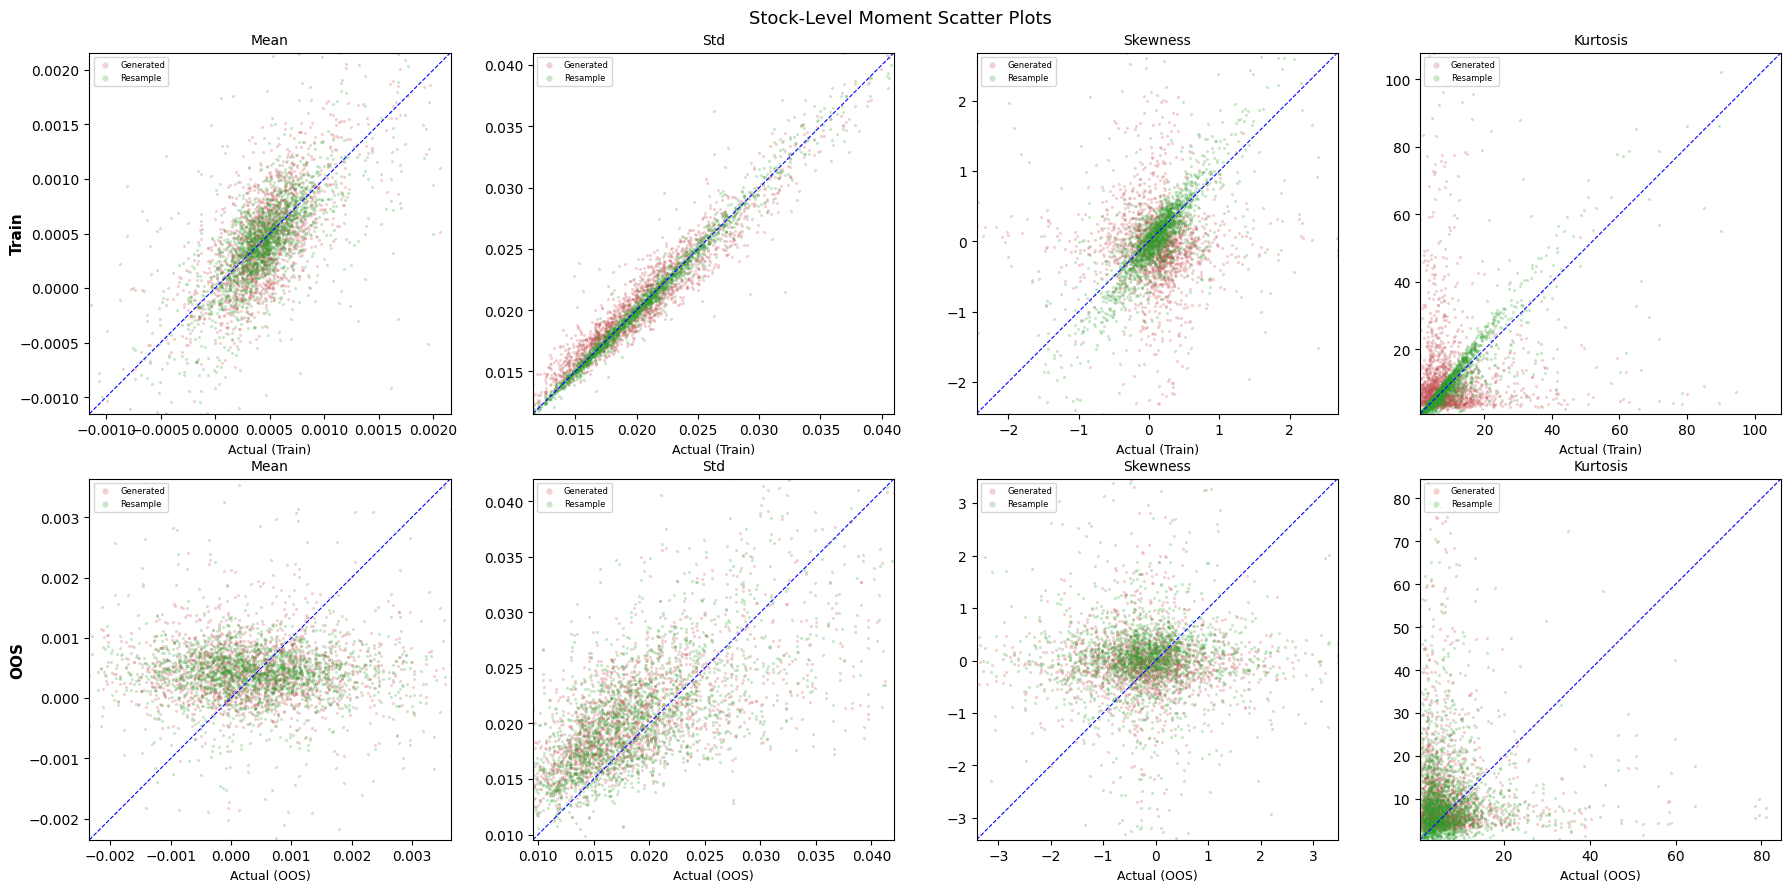

In [39]:
from scipy.stats import skew, kurtosis
## Stock-Level Moment Scatter Plots
MOMENTS = {
    "Mean":     lambda X: np.nanmean(X, axis=0),
    "Std":      lambda X: np.nanstd(X, axis=0),
    "Skewness": lambda X: skew(X, axis=0, nan_policy="omit"),
    "Kurtosis": lambda X: kurtosis(X, axis=0, nan_policy="omit"),
}

m_actual_tr  = {k: fn(R_train) for k, fn in MOMENTS.items()}
m_actual_oos = {k: fn(R_test)  for k, fn in MOMENTS.items()}
m_gen        = {k: fn(R_gen)   for k, fn in MOMENTS.items()}
m_rs         = {k: fn(R_rs)    for k, fn in MOMENTS.items()}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
# per moments
for col, (mname, _) in enumerate(MOMENTS.items()):
    # per horizontal axis
    for row, (actual_label, m_actual) in enumerate([
            ("Train", m_actual_tr),
            ("OOS",   m_actual_oos)]):
        ax  = axes[row, col]
        x   = m_actual[mname]
        y_g = m_gen[mname]
        y_r = m_rs[mname]

        # do not draw the NaN value
        mask_g = np.isfinite(x) & np.isfinite(y_g)
        mask_r = np.isfinite(x) & np.isfinite(y_r)
        all_vals = np.concatenate([x[mask_g], y_g[mask_g],
                                   x[mask_r], y_r[mask_r]])
        ax.scatter(x[mask_g], y_g[mask_g], s=5, alpha=0.25, linewidths=0,
                   color="#c44e52", label="Generated")
        ax.scatter(x[mask_r], y_r[mask_r], s=5, alpha=0.25, linewidths=0,
                   color="#2ca02c", label="Resample")
        lo = np.percentile(all_vals, 1) # dont plot the outliers, otherwise it look insane
        hi = np.percentile(all_vals, 99)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.plot([lo, hi], [lo, hi], "b--", lw=0.8)
        ax.set_xlabel(f"Actual ({actual_label})", fontsize=9)
        ax.set_title(mname, fontsize=10)
        ax.set_aspect("equal") # for
        ax.legend(fontsize=6, markerscale=2, loc="upper left")

# side labela
for row, label in enumerate(["Train", "OOS"]):
    axes[row, 0].annotate(label, xy=(-0.22, 0.5), xycoords="axes fraction",
                          fontsize=11, rotation=90, va="center", fontweight="bold")
fig.suptitle("Stock-Level Moment Scatter Plots", fontsize=13)
fig.tight_layout()
plt.show()

In [40]:
col_w = 14
header = f"{'':22}" + "".join(f"{m:<{col_w}}" for m in MOMENTS)
print("Pearson R²")
print(header)
print("-" * len(header))
for actual_label, m_actual in [("Train", m_actual_tr), ("OOS", m_actual_oos)]:
    for model_label, m_pred in [("Generated", m_gen), ("Resample", m_rs)]:
        label = f"{actual_label} {model_label}"
        row = f"{label:<22}"
        for mname in MOMENTS:
            x, y = m_actual[mname], m_pred[mname]
            mask = np.isfinite(x) & np.isfinite(y)
            r, _ = pearsonr(x[mask], y[mask])
            row += f"{r**2:<{col_w}.4f}"
        print(row)
    print()

Pearson R²
                      Mean          Std           Skewness      Kurtosis      
------------------------------------------------------------------------------
Train Generated       0.5818        0.9235        0.0006        0.0019        
Train Resample        0.4895        0.9828        0.7184        0.9243        

OOS Generated         0.0001        0.4609        0.0000        0.0004        
OOS Resample          0.0000        0.4521        0.0011        0.0008        



## Kolmogorov–Smirnov test (stock level)

We perform KS test for train/test set and illustrates the distribution of p-values across stocks. We set p=0.05 as the threshold for passing the test, and count the fraction of stocks that pass the test for both generated and baseline samples against the baseline, and the diffusion model performs worse.


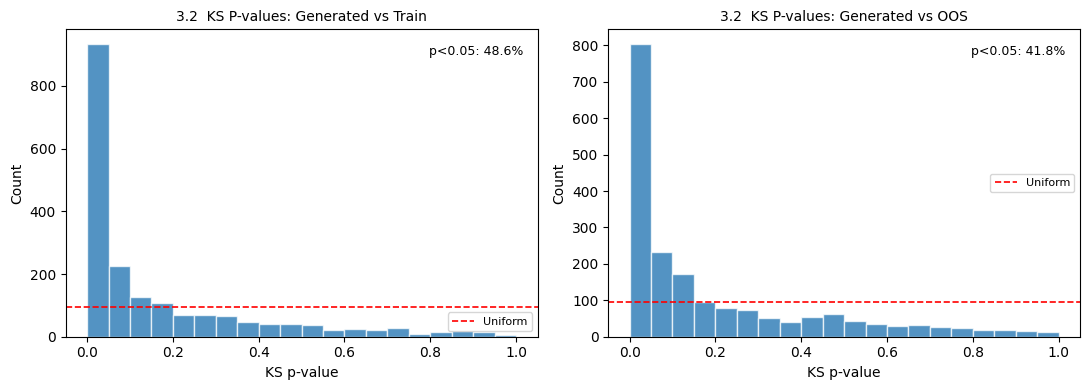

In [41]:
## 3.2 Distribution of KS Test P-values
pvals_gen_train, pvals_gen_oos = [], []
pvals_rs_train,  pvals_rs_oos  = [], []
S = R_train.shape[1]
for s in range(S):
    g   = R_gen[:, s];   g   = g[np.isfinite(g)]
    rs  = R_rs[:, s];    rs  = rs[np.isfinite(rs)]
    tr  = R_train[:, s]; tr  = tr[np.isfinite(tr)]
    oos = R_test[:, s];  oos = oos[np.isfinite(oos)]
    if len(g)  > 5 and len(tr)  > 5: pvals_gen_train.append(ks_2samp(g,  tr).pvalue)
    if len(g)  > 5 and len(oos) > 5: pvals_gen_oos.append(  ks_2samp(g,  oos).pvalue)
    if len(rs) > 5 and len(tr)  > 5: pvals_rs_train.append( ks_2samp(rs, tr).pvalue)
    if len(rs) > 5 and len(oos) > 5: pvals_rs_oos.append(   ks_2samp(rs, oos).pvalue)

pvals_gen_train = np.array(pvals_gen_train)
pvals_gen_oos   = np.array(pvals_gen_oos)
pvals_rs_train  = np.array(pvals_rs_train)
pvals_rs_oos    = np.array(pvals_rs_oos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for ax, pv, label in [(ax1, pvals_gen_train, "Generated vs Train"),
                      (ax2, pvals_gen_oos,   "Generated vs OOS")]:
    n_bins = 20
    ax.hist(pv, bins=n_bins, range=(0, 1), color="#1a6faf", alpha=0.75, edgecolor="white")
    ax.axhline(len(pv) / n_bins, color="red", linestyle="--", lw=1.2, label="Uniform")
    ax.set_xlabel("KS p-value", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"3.2  KS P-values: {label}", fontsize=10)
    ax.legend(fontsize=8)
    frac = (pv < 0.05).mean()
    ax.text(0.97, 0.95, f"p<0.05: {frac:.1%}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9)

fig.tight_layout()
plt.show()

In [42]:
col_w = 20
header = f"{'':16}" + f"{'Generated':<{col_w}}" + f"{'Resample':<{col_w}}"
print("KS p>0.05:")
print(header)
print("-" * len(header))
for label, pv_g, pv_r in [
    ("vs Train", pvals_gen_train, pvals_rs_train),
    ("vs OOS",   pvals_gen_oos,   pvals_rs_oos),
]:
    gen_val = f"{(pv_g > 0.05).mean():.1%}"
    rs_val  = f"{(pv_r > 0.05).mean():.1%}"
    print(f"{label:<16}{gen_val:<{col_w}}{rs_val:<{col_w}}")

KS p>0.05:
                Generated           Resample            
--------------------------------------------------------
vs Train        51.4%               100.0%              
vs OOS          58.2%               71.2%               


## Dispersion Comparison

We decompose the returns into systematic (factor-driven) and idiosyncratic components to see how well the model captures each part. And we plot histogram of std on each part and combined, and summarize them via w1 distance.

The results shows that the diffusion model have the same level performance on the systematic level, however the idiosyncratic highly deviate from the OOS. And this deviation dominates the total return level such that diffusion model is worse than the baseline.

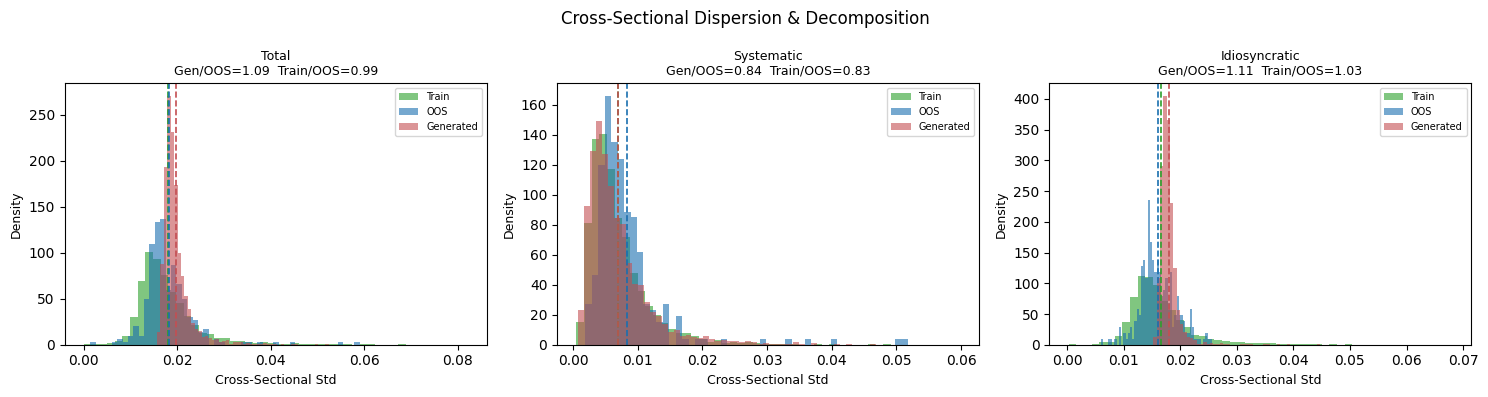

In [43]:
beta_c    = train_model.beta[:, col_indices] # beta
res_std_c = train_model.res_std[col_indices]

# training part construction
sys_train  = train_model.F.values.astype(np.float32) @ beta_c
idio_train = train_model.residuals[:, col_indices].astype(np.float32)
# test part construction
test_beta_c = test_model.beta[:, col_indices_test]
sys_oos  = test_model.F.values.astype(np.float32) @ test_beta_c
idio_oos = test_model.residuals[:, col_indices_test].astype(np.float32)
# generated part construction
sys_gen  = fs_full @ beta_c
t_noise = np.random.default_rng(42).standard_t(train_model.res_df, size=sys_gen.shape).astype(np.float32)
idio_gen = t_noise * np.sqrt((train_model.res_df - 2) / train_model.res_df) * res_std_c

panels = [
    ("Total",         R_gen, R_test,  R_train),
    ("Systematic",    sys_gen,  sys_oos,   sys_train),
    ("Idiosyncratic", idio_gen, idio_oos,  idio_train),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (comp, gmat, omat, tmat) in zip(axes, panels):
    gv = np.nanstd(gmat, axis=1)
    ov = np.nanstd(omat, axis=1)
    tv = np.nanstd(tmat, axis=1)
    ax.hist(tv, bins=50, density=True, alpha=0.60, color="#2ca02c", label="Train")
    ax.hist(ov, bins=50, density=True, alpha=0.60, color="#1a6faf", label="OOS")
    ax.hist(gv, bins=50, density=True, alpha=0.60, color="#c44e52", label="Generated")
    for val, col in [(tv.mean(), "#2ca02c"), (ov.mean(), "#1a6faf"), (gv.mean(), "#c44e52")]:
        ax.axvline(val, color=col, linestyle="--", lw=1.2)
    r_gen = gv.mean() / (ov.mean() + 1e-12)
    r_tr  = tv.mean() / (ov.mean() + 1e-12)
    ax.set_xlabel("Cross-Sectional Std", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.set_title(comp + "\nGen/OOS=%.2f  Train/OOS=%.2f" % (r_gen, r_tr), fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle("Cross-Sectional Dispersion & Decomposition", fontsize=12)
fig.tight_layout()
plt.show()

In [44]:
row_idx_r = row_idx[row_idx < len(sys_train)]
sys_rs    = sys_train[row_idx_r]
idio_rs   = idio_train[row_idx_r]

rs_panels = [
    ("Total",         R_rs,    R_test),
    ("Systematic",    sys_rs,  sys_oos),
    ("Idiosyncratic", idio_rs, idio_oos),
]

col_w = 20
header = f"{'Component':<16}{'W1(Gen, OOS)':<{col_w}}{'W1(Resample, OOS)':<{col_w}}"
print("Wasserstein-1 Distance of Cross-Sectional Std (vs OOS):")
print(header)
print("-" * len(header))
for (comp, gmat, omat, _), (_, rsmat, _) in zip(panels, rs_panels):
    gv  = np.nanstd(gmat,  axis=1); gv  = gv[np.isfinite(gv)]
    ov  = np.nanstd(omat,  axis=1); ov  = ov[np.isfinite(ov)]
    rsv = np.nanstd(rsmat, axis=1); rsv = rsv[np.isfinite(rsv)]
    print(f"{comp:<16}{w1dist(gv, ov):<{col_w}.4f}{w1dist(rsv, ov):<{col_w}.4f}")

Wasserstein-1 Distance of Cross-Sectional Std (vs OOS):
Component       W1(Gen, OOS)        W1(Resample, OOS)   
--------------------------------------------------------
Total           0.0023              0.0013              
Systematic      0.0014              0.0014              
Idiosyncratic   0.0022              0.0014              
